# 0. Setup & Reproducibility

In [43]:
# --- Install extra dependencies ---
!pip install open_clip_torch --quiet

In [44]:
# --- Imports ---
import random
import time
import math
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
 
import open_clip

In [45]:
# --- Set the seeds to 42 ---
# Helps with reproducilibity
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
 
# GPU specs (Kaggle)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"Total VRAM   : {total_vram:.1f} GB")
print(f"PyTorch      : {torch.__version__}")
print(f"open_clip    : {open_clip.__version__}")

Device       : cuda
GPU          : Tesla T4
Total VRAM   : 14.6 GB
PyTorch      : 2.10.0+cu128
open_clip    : 3.3.0


# 1. Data exploration

In [46]:
# Uploaded the dataset to kaggle as a private dataset
# Change the following path, if your dataset resides in local or some other place in some other cloud service
DATASET_ROOT = Path("/kaggle/input/datasets/oooessteii/di725-project-dataset/DI725_project_dataset")

# Image and csv paths RELATIVE to the root directory
CSV_PATH   = DATASET_ROOT / "captions.csv"
IMG_DIR    = DATASET_ROOT / "images"
 
assert CSV_PATH.exists(), f"captions.csv not found at {CSV_PATH}"
assert IMG_DIR.exists(), f"images/ folder not found at {IMG_DIR}"
 
# Load CSV
df = pd.read_csv(CSV_PATH)
print(f"Dataset shape : {df.shape}  ({df.shape[0]} images, {df.shape[1]} columns)")
print(f"\nColumn names  : {list(df.columns)}")
print(f"\nFirst 3 rows  :")
df.head(3)

Dataset shape : (10000, 14)  (10000 images, 14 columns)

Column names  : ['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

First 3 rows  :


,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."


Null values per column:
  None — dataset is complete.


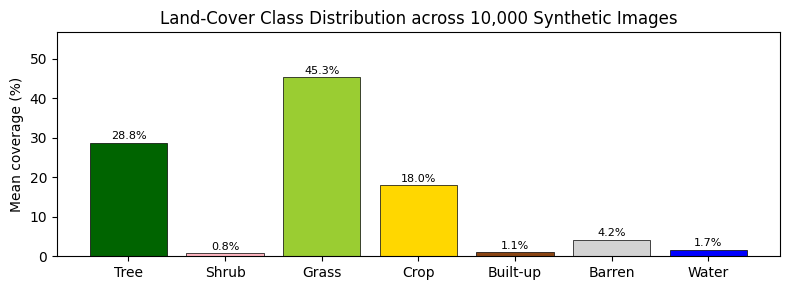

Figure saved: composition_distribution.png


In [47]:
# --- Check class distribution ---
# Null check
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts[null_counts > 0] if null_counts.any() else "  None — dataset is complete.")
 
# Composition class distribution
COMP_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]
CLASS_COLORS = ["#006400", "#FFB6C1", "#9ACD32", "#FFD700", "#8B4513", "#D3D3D3", "#0000FF"]
 
means = df[COMP_COLS].mean()
 
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(COMP_COLS, means, color=CLASS_COLORS, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Mean coverage (%)")
ax.set_title("Land-Cover Class Distribution across 10,000 Synthetic Images")
ax.set_ylim(0, means.max() * 1.25)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("composition_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: composition_distribution.png")

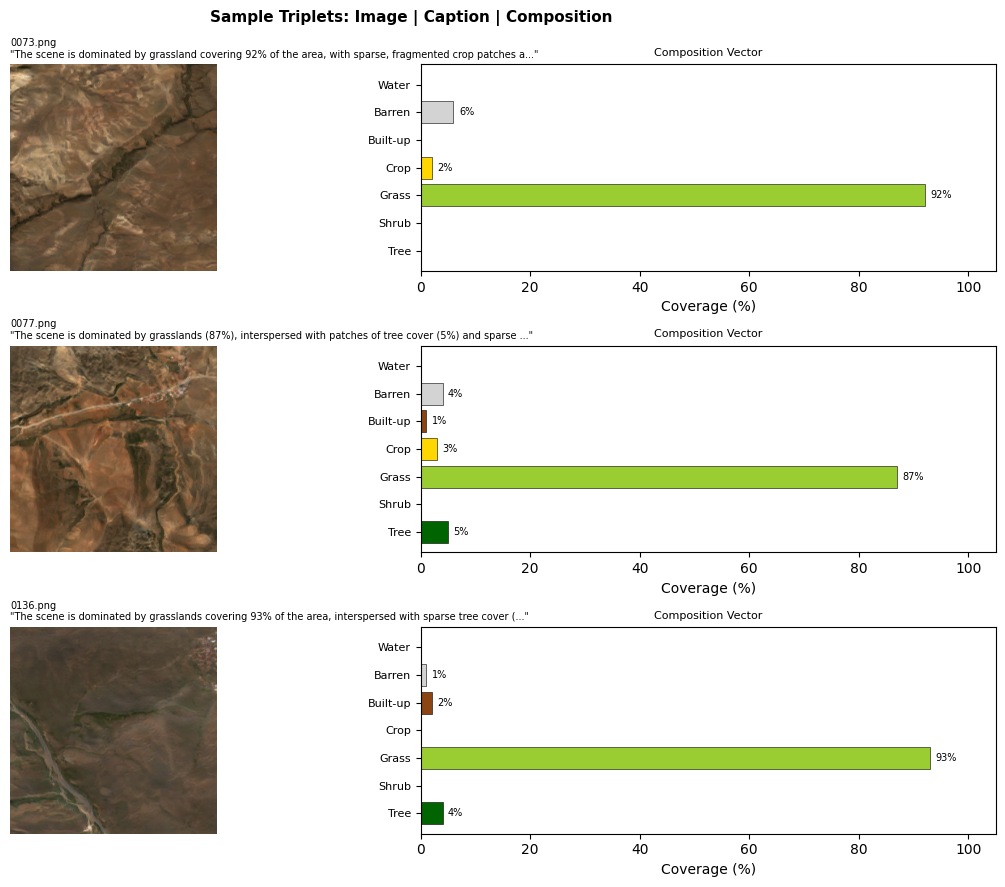

Figure saved: sample_triplets.png


In [48]:
# --- Show 3 sample triplets: image + caption + composition bar ---
CAPTION_COL = "hybrid_qwen3-vl-8b"
SAMPLE_INDICES = [0, 1, 2]
 
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
fig.suptitle("Sample Triplets: Image | Caption | Composition", fontsize=11, fontweight="bold")
 
for row_idx, df_idx in enumerate(SAMPLE_INDICES):
    row = df.iloc[df_idx]
    img_path = IMG_DIR / row["filename"]
 
    # Image
    ax_img = axes[row_idx, 0]
    try:
        img = Image.open(img_path).convert("RGB")
        ax_img.imshow(img)
    except FileNotFoundError:
        ax_img.text(0.5, 0.5, f"Image not found:\n{row['filename']}",
                    ha="center", va="center", transform=ax_img.transAxes, color="red")
    ax_img.axis("off")
    caption_text = str(row[CAPTION_COL])
    ax_img.set_title(f"{row['filename']}\n\"{caption_text[:100]}{'...' if len(caption_text)>100 else ''}\"",
                     fontsize=7, loc="left", wrap=True)
 
    # Composition bar
    ax_bar = axes[row_idx, 1]
    comp_vals = [row[c] for c in COMP_COLS]
    y_pos = range(len(COMP_COLS))
    ax_bar.barh(list(y_pos), comp_vals, color=CLASS_COLORS, edgecolor="black", linewidth=0.4)
    ax_bar.set_yticks(list(y_pos))
    ax_bar.set_yticklabels(COMP_COLS, fontsize=8)
    ax_bar.set_xlabel("Coverage (%)")
    ax_bar.set_xlim(0, 105)
    for i, val in enumerate(comp_vals):
        if val > 0:
            ax_bar.text(val + 1, i, f"{val}%", va="center", fontsize=7)
    ax_bar.set_title("Composition Vector", fontsize=8)
 
plt.tight_layout()
plt.savefig("sample_triplets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: sample_triplets.png")
 

# 2. Data Pipeline

In [49]:
class CompRSDataset(Dataset):
    """
    PyTorch Dataset for CompRS-CLIP tri-modal training.
 
    Each sample returns:
        image_tensor  : torch.Tensor of shape (3, 224, 224)
        token_ids     : torch.Tensor of shape (77,), CLIP tokenized caption
        comp_vector   : torch.Tensor of shape (7,), normalized composition [0, 1]
    """
 
    COMP_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]
 
    def __init__(self, df: pd.DataFrame, img_dir: Path, caption_col: str,
                 transform, tokenizer):
        self.df          = df.reset_index(drop=True)
        self.img_dir     = Path(img_dir)
        self.caption_col = caption_col
        self.transform   = transform
        self.tokenizer   = tokenizer
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
 
        # Image
        img_path = self.img_dir / row["filename"]
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            # Return blank image if file missing, just in case
            image = Image.new("RGB", (224, 224), color=(0, 0, 0))
        image_tensor = self.transform(image)
 
        # Text
        caption = str(row[self.caption_col])
        token_ids = self.tokenizer([caption])[0]
 
        # Composition
        comp_raw = row[self.COMP_COLS].values.astype(np.float32)
        comp_vector = torch.tensor(comp_raw / 100.0, dtype=torch.float32) # percentages between [0,1]
 
        return image_tensor, token_ids, comp_vector

In [50]:
# Follow the official documentation to load RemoteClip weights
# https://github.com/ChenDelong1999/RemoteCLIP?tab=readme-ov-file#load-remoteclip
from huggingface_hub import hf_hub_download
 
print("Downloading RemoteCLIP-ViT-B-32 weights from HuggingFace...")
checkpoint_path = hf_hub_download(
    repo_id="chendelong/RemoteCLIP",
    filename="RemoteCLIP-ViT-B-32.pt",
    cache_dir="checkpoints"
)
print(f"Checkpoint saved to: {checkpoint_path}")
 
# Initialize ViT-B-32 architecture with open_clip (no pretrained weights yet)
print("Initializing ViT-B-32 architecture and loading RemoteCLIP weights...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32")
 
# Load RemoteCLIP weights into the architecture
state_dict = torch.load(checkpoint_path, map_location="cpu")
clip_model.load_state_dict(state_dict)
 
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
print("RemoteCLIP-ViT-B-32 loaded successfully.")

Checkpoint saved to: checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt
Initializing ViT-B-32 architecture and loading RemoteCLIP weights...


RemoteCLIP-ViT-B-32 loaded successfully.


In [51]:
# --- Build micro-dataset ---
MICRO_N     = 500
TRAIN_N     = 400
VAL_N       = 100
CAPTION_COL = "hybrid_qwen3-vl-8b"
 
df_micro = df.sample(n=MICRO_N, random_state=SEED).reset_index(drop=True)
df_train = df_micro.iloc[:TRAIN_N]
df_val   = df_micro.iloc[TRAIN_N:]
 
print(f"Micro-dataset : {MICRO_N} samples  (train={TRAIN_N}, val={VAL_N})")
print(f"Caption column: {CAPTION_COL}")
 
train_dataset = CompRSDataset(df_train, IMG_DIR, CAPTION_COL, clip_preprocess, clip_tokenizer)
val_dataset   = CompRSDataset(df_val, IMG_DIR, CAPTION_COL, clip_preprocess, clip_tokenizer)
 
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
 
print(f"Train batches : {len(train_loader)}  (batch_size={BATCH_SIZE})")
print(f"Val batches   : {len(val_loader)}")
 
# Inspect one batch
sample_imgs, sample_tokens, sample_comps = next(iter(train_loader))
print("One batch shapes:")
print(f"  image_tensor : {sample_imgs.shape}     dtype={sample_imgs.dtype}")
print(f"  token_ids    : {sample_tokens.shape}   dtype={sample_tokens.dtype}")
print(f"  comp_vector  : {sample_comps.shape}    dtype={sample_comps.dtype}")
print(f"\nComp vector value range: [{sample_comps.min():.3f}, {sample_comps.max():.3f}]  "
      f"(should be in [0, 1])")

Micro-dataset : 500 samples  (train=400, val=100)
Caption column: hybrid_qwen3-vl-8b
Train batches : 13  (batch_size=32)
Val batches   : 4
One batch shapes:
  image_tensor : torch.Size([32, 3, 224, 224])     dtype=torch.float32
  token_ids    : torch.Size([32, 77])   dtype=torch.int64
  comp_vector  : torch.Size([32, 7])    dtype=torch.float32

Comp vector value range: [0.000, 1.000]  (should be in [0, 1])


# 3. Model Initialization


In [52]:
class CompositionMLP(nn.Module):
    """
    Lightweight MLP that projects a 7-dimensional land-cover composition vector
    into the 512-dimensional shared CLIP embedding space.
 
    Architecture: Linear(7→128) → GELU → LayerNorm
                  Linear(128→256) → GELU → LayerNorm
                  Linear(256→512)
    Output is L2-normalized to match the CLIP embedding convention.
    """
 
    def __init__(self, in_dim: int = 7, hidden: list = [128, 256], out_dim: int = 512):
        super().__init__()
        layers = []
        prev_dim = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev_dim, h),
                nn.GELU(),
                nn.LayerNorm(h),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, out_dim))
        self.net = nn.Sequential(*layers)
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x)
        return F.normalize(out, dim=-1)
 

In [53]:
# --- Initiate encoders, projections and composition MLP ---
# Freeze CLIP encoders
clip_model = clip_model.to(DEVICE)
for param in clip_model.parameters():
    param.requires_grad = False
clip_model.eval()
 
# Instantiate composition MLP
comp_mlp = CompositionMLP(in_dim=7, hidden=[128, 256], out_dim=512).to(DEVICE)
 
# --- Projection heads: sit on top of frozen encoders, trained by composition loss ---
# These are the extra layers over CLIP encoders carrying composition-aware geometry at inference time.
vision_proj = nn.Linear(512, 512, bias=False).to(DEVICE) 
# A linear projection of the same dimension acts as a learnable rotation/scaling of thefrozen CLIP embedding space
text_proj   = nn.Linear(512, 512, bias=False).to(DEVICE)
 
# Initialize as identity so training starts from the pre-trained Remote-Clip weights
nn.init.eye_(vision_proj.weight)
nn.init.eye_(text_proj.weight)
 
# Temperature is learnable too
log_tau = nn.Parameter(torch.tensor(math.log(1.0 / 0.07), dtype=torch.float32).to(DEVICE))
 
# Parameter counts to check total 
frozen_params    = sum(p.numel() for p in clip_model.parameters())
trainable_params = (sum(p.numel() for p in comp_mlp.parameters()) +
                    sum(p.numel() for p in vision_proj.parameters()) +
                    sum(p.numel() for p in text_proj.parameters()) +
                    log_tau.numel())
 
print(f"Frozen parameters   (CLIP encoders)           : {frozen_params:>12,}")
print(f"Trainable parameters (MLP + proj heads + tau) : {trainable_params:>12,}")
print(f"Trainable / Total ratio                       : {trainable_params / (frozen_params + trainable_params):.4%}")

Frozen parameters   (CLIP encoders)           :  151,277,313
Trainable parameters (MLP + proj heads + tau) :      690,689
Trainable / Total ratio                       : 0.4545%


In [54]:
# --- Forward pass sanity check ---
clip_model.eval()
comp_mlp.eval()
vision_proj.eval()
text_proj.eval()
 
with torch.no_grad():
    imgs_gpu    = sample_imgs.to(DEVICE)
    tokens_gpu  = sample_tokens.to(DEVICE)
    comps_gpu   = sample_comps.to(DEVICE)
 
    # Raw frozen CLIP features
    raw_E_v = clip_model.encode_image(imgs_gpu)
    raw_E_t = clip_model.encode_text(tokens_gpu)
 
    # Pass through projection heads then normalize
    E_v = F.normalize(vision_proj(raw_E_v), dim=-1)
    E_t = F.normalize(text_proj(raw_E_t), dim=-1)
    E_c = comp_mlp(comps_gpu)
 
print("Forward pass — embedding shapes:")
print(f"  raw_E_v (frozen CLIP image)  : {raw_E_v.shape}")
print(f"  E_v (after vision_proj)      : {E_v.shape}   norm={E_v.norm(dim=-1).mean():.4f}")
print(f"  E_t (after text_proj)        : {E_t.shape}   norm={E_t.norm(dim=-1).mean():.4f}")
print(f"  E_c (composition MLP)        : {E_c.shape}   norm={E_c.norm(dim=-1).mean():.4f}")
print("\nAll projected embeddings are (batch, 512) and L2-normalized.")

Forward pass — embedding shapes:
  raw_E_v (frozen CLIP image)  : torch.Size([32, 512])
  E_v (after vision_proj)      : torch.Size([32, 512])   norm=1.0000
  E_t (after text_proj)        : torch.Size([32, 512])   norm=1.0000
  E_c (composition MLP)        : torch.Size([32, 512])   norm=1.0000

All projected embeddings are (batch, 512) and L2-normalized.


# 4. Loss Function


In [55]:
def tri_modal_infonce_loss(
    E_v: torch.Tensor,
    E_t: torch.Tensor,
    E_c: torch.Tensor,
    log_tau: nn.Parameter,
    lambda1: float = 1.0,
    lambda2: float = 1.0,
    lambda3: float = 1.0,
):
    """
    Tri-modal symmetric InfoNCE loss.
 
    For each modality pair (V,T), (V,C), (T,C), computes a symmetric
    cross-entropy loss over the scaled cosine similarity matrix.
    Diagonal entries are true positives (matched triplets in the batch).
 
    Args:
        E_v, E_t, E_c : L2-normalized embeddings, shape (N, D)
        log_tau        : learnable log-temperature scalar
        lambda1/2/3    : loss weights for VT, VC, TC pairs
 
    Returns:
        L_total, L_VT, L_VC, L_TC : scalar tensors
    """
    N = E_v.shape[0]
    targets = torch.arange(N, device=E_v.device)
    tau = log_tau.exp()
 
    def symmetric_ce(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
        S = (A @ B.T) * tau
        loss_ab = F.cross_entropy(S, targets)
        loss_ba = F.cross_entropy(S.T, targets)
        return 0.5 * (loss_ab + loss_ba)
 
    L_VT = symmetric_ce(E_v, E_t)
    L_VC = symmetric_ce(E_v, E_c)
    L_TC = symmetric_ce(E_t, E_c)
 
    L_total = lambda1 * L_VT + lambda2 * L_VC + lambda3 * L_TC
    return L_total, L_VT, L_VC, L_TC

In [56]:
print("Running loss unit test with random normalized embeddings...")
 
N_test = 16
D      = 512
E_v_r  = F.normalize(torch.randn(N_test, D, device=DEVICE), dim=-1)
E_t_r  = F.normalize(torch.randn(N_test, D, device=DEVICE), dim=-1)
E_c_r  = F.normalize(torch.randn(N_test, D, device=DEVICE), dim=-1)
tau_r  = nn.Parameter(torch.tensor(math.log(1.0 / 0.07)).to(DEVICE))
 
L_total_r, L_VT_r, L_VC_r, L_TC_r = tri_modal_infonce_loss(E_v_r, E_t_r, E_c_r, tau_r)
 
print(f"L_VT   = {L_VT_r.item():.4f}")
print(f"L_VC   = {L_VC_r.item():.4f}")
print(f"L_TC   = {L_TC_r.item():.4f}")
print(f"L_total= {L_total_r.item():.4f}")
 
L_total_r.backward()
print(f"Backward pass completed without crash")
print(f"MLP grad check: {'None' if comp_mlp.net[0].weight.grad is None else 'Gradient Exists'}")
print("(None is expected since MLP was not in this unit test forward pass)")
 
# Confirm that gradient flows to MLP with actual MLP output
E_c_real = comp_mlp(comps_gpu[:N_test])
L_total_real, _, _, _ = tri_modal_infonce_loss(
    E_v[:N_test], E_t[:N_test], E_c_real, log_tau
)
L_total_real.backward()
mlp_grad = comp_mlp.net[0].weight.grad
print(f"\nMLP gradient (first layer weight) norm: {mlp_grad.norm().item():.6f}")
print(f"Gradient flows to MLP: {'YES' if mlp_grad is not None else 'NO'}")
print(f"log_tau gradient: {log_tau.grad.item():.6f}")
print("\nUnit tests did not break gradient flow.")

Running loss unit test with random normalized embeddings...
L_VT   = 3.0263
L_VC   = 2.7917
L_TC   = 3.3631
L_total= 9.1811
Backward pass completed without crash
MLP grad check: None
(None is expected since MLP was not in this unit test forward pass)

MLP gradient (first layer weight) norm: 1.309158
Gradient flows to MLP: YES
log_tau gradient: 0.009607

Unit tests did not break gradient flow.


# 5. Micro Training Loop


In [57]:
# --- Optimizer: MLP + projection heads + log_tau ---
optimizer = torch.optim.AdamW(
    list(comp_mlp.parameters()) +
    list(vision_proj.parameters()) +
    list(text_proj.parameters()) +
    [log_tau],
    lr=1e-3,
    weight_decay=1e-4
)

# Loss contribution parameters, could be investigated more as an ablation study
LAMBDA1, LAMBDA2, LAMBDA3 = 1.0, 1.0, 1.0
N_EPOCHS = 5
 
history = {
    "train_L_total": [], "train_L_VT": [], "train_L_VC": [], "train_L_TC": [],
    "val_L_total":   []
}
 
print(f"Starting micro training: {N_EPOCHS} epochs, {len(train_loader)} train batches, "
      f"{len(val_loader)} val batches")
print(f"Trainable params: {trainable_params:,}  |  Optimizer: AdamW lr=1e-3  wd=1e-4")
print(f"Trainable components: comp_mlp + vision_proj + text_proj + log_tau")
print("-" * 65)
 
torch.cuda.reset_peak_memory_stats()
epoch_times = []
 
for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
 
    # Training
    comp_mlp.train()
    vision_proj.train()
    text_proj.train()
    clip_model.eval()
    epoch_losses = {"L_total": [], "L_VT": [], "L_VC": [], "L_TC": []}
 
    for batch_imgs, batch_tokens, batch_comps in train_loader:
        batch_imgs   = batch_imgs.to(DEVICE)
        batch_tokens = batch_tokens.to(DEVICE)
        batch_comps  = batch_comps.to(DEVICE)
 
        # Extract raw frozen CLIP features, 
        # Avoid wasting huge VRAM for CLIP ViT backbone gradient graph with torch.no_grad() 
        with torch.no_grad():
            raw_E_v = clip_model.encode_image(batch_imgs)
            raw_E_t = clip_model.encode_text(batch_tokens)
 
        # Pass through trainable projection heads, gradients flow here
        E_v = F.normalize(vision_proj(raw_E_v), dim=-1)
        E_t = F.normalize(text_proj(raw_E_t), dim=-1)
        E_c = comp_mlp(batch_comps)
 
        L_total, L_VT, L_VC, L_TC = tri_modal_infonce_loss(
            E_v, E_t, E_c, log_tau, LAMBDA1, LAMBDA2, LAMBDA3
        )
 
        optimizer.zero_grad()
        L_total.backward()
        optimizer.step()
 
        epoch_losses["L_total"].append(L_total.item())
        epoch_losses["L_VT"].append(L_VT.item())
        epoch_losses["L_VC"].append(L_VC.item())
        epoch_losses["L_TC"].append(L_TC.item())
 
    # Validation
    comp_mlp.eval()
    vision_proj.eval()
    text_proj.eval()
    val_losses = []
    with torch.no_grad():
        for batch_imgs, batch_tokens, batch_comps in val_loader:
            batch_imgs   = batch_imgs.to(DEVICE)
            batch_tokens = batch_tokens.to(DEVICE)
            batch_comps  = batch_comps.to(DEVICE)
 
            raw_E_v = clip_model.encode_image(batch_imgs)
            raw_E_t = clip_model.encode_text(batch_tokens)
            E_v = F.normalize(vision_proj(raw_E_v), dim=-1)
            E_t = F.normalize(text_proj(raw_E_t), dim=-1)
            E_c = comp_mlp(batch_comps)
 
            L_total_val, _, _, _ = tri_modal_infonce_loss(
                E_v, E_t, E_c, log_tau, LAMBDA1, LAMBDA2, LAMBDA3
            )
            val_losses.append(L_total_val.item())
 
    # Log epoch stats
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
 
    avg = {k: np.mean(v) for k, v in epoch_losses.items()}
    avg_val = np.mean(val_losses)
 
    history["train_L_total"].append(avg["L_total"])
    history["train_L_VT"].append(avg["L_VT"])
    history["train_L_VC"].append(avg["L_VC"])
    history["train_L_TC"].append(avg["L_TC"])
    history["val_L_total"].append(avg_val)
 
    print(f"Epoch {epoch}/{N_EPOCHS}  "
          f"L_total={avg['L_total']:.4f}  "
          f"L_VT={avg['L_VT']:.4f}  "
          f"L_VC={avg['L_VC']:.4f}  "
          f"L_TC={avg['L_TC']:.4f}  "
          f"val={avg_val:.4f}  "
          f"tau={log_tau.exp().item():.3f}  "
          f"time={epoch_time:.1f}s")
 
print("-" * 65)
print("Micro training complete.")


Starting micro training: 5 epochs, 13 train batches, 4 val batches
Trainable params: 690,689  |  Optimizer: AdamW lr=1e-3  wd=1e-4
Trainable components: comp_mlp + vision_proj + text_proj + log_tau
-----------------------------------------------------------------
Epoch 1/5  L_total=7.8913  L_VT=2.6618  L_VC=2.6801  L_TC=2.5494  val=5.4791  tau=14.400  time=5.1s
Epoch 2/5  L_total=6.0916  L_VT=1.9232  L_VC=2.1793  L_TC=1.9891  val=4.7605  tau=14.565  time=3.4s
Epoch 3/5  L_total=5.1402  L_VT=1.4782  L_VC=1.9553  L_TC=1.7067  val=4.6089  tau=14.762  time=3.4s
Epoch 4/5  L_total=4.5126  L_VT=1.1556  L_VC=1.7861  L_TC=1.5709  val=4.7480  tau=14.978  time=3.5s
Epoch 5/5  L_total=4.0879  L_VT=0.9239  L_VC=1.7012  L_TC=1.4628  val=4.6668  tau=15.195  time=3.5s
-----------------------------------------------------------------
Micro training complete.


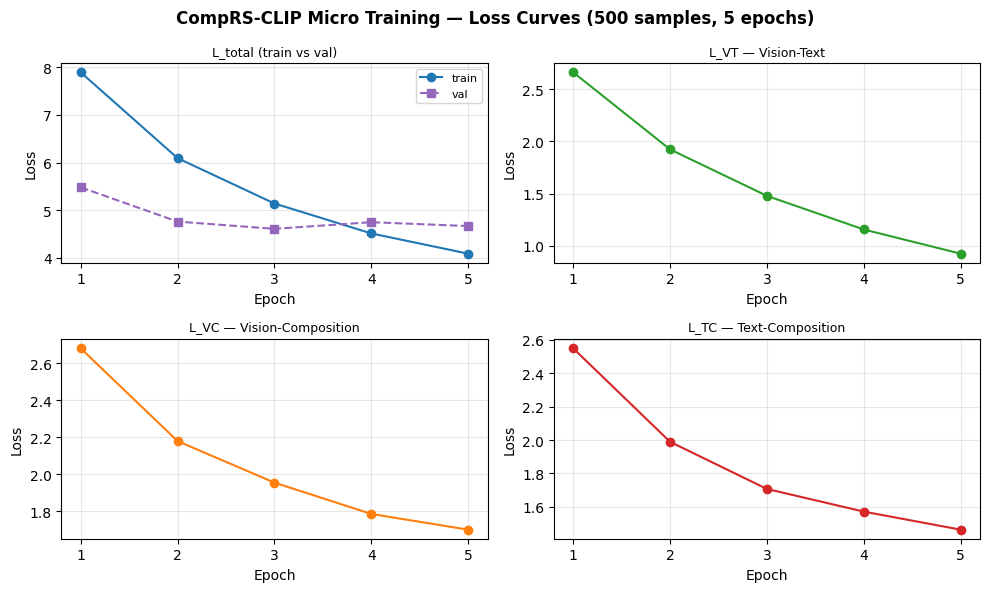

Figure saved: loss_curves.png


In [58]:
# --- Plot loss curves ---
epochs = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("CompRS-CLIP Micro Training — Loss Curves (500 samples, 5 epochs)", fontweight="bold")
 
plot_configs = [
    ("train_L_total", "L_total (train vs val)", "tab:blue", True),
    ("train_L_VT", "L_VT — Vision-Text", "tab:green", False),
    ("train_L_VC", "L_VC — Vision-Composition", "tab:orange", False),
    ("train_L_TC", "L_TC — Text-Composition", "tab:red", False),
]

for ax, (key, title, color, show_val) in zip(axes.flat, plot_configs):
    ax.plot(epochs, history[key], marker="o", color=color, label="train", linewidth=1.5)
    if show_val:
        ax.plot(epochs, history["val_L_total"], marker="s", color="tab:purple",
                linestyle="--", label="val", linewidth=1.5)
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(list(epochs))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: loss_curves.png")

# 6. Feasibility Summary


In [59]:
# --- Memory usage ---
peak_vram_bytes = torch.cuda.max_memory_allocated()
peak_vram_gb    = peak_vram_bytes / 1024**3
print(f"Peak GPU memory allocated : {peak_vram_gb:.3f} GB  ({peak_vram_bytes / 1024**2:.1f} MB)")
print(f"Total VRAM available      : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"VRAM headroom remaining   : {torch.cuda.get_device_properties(0).total_memory / 1024**3 - peak_vram_gb:.2f} GB")

Peak GPU memory allocated : 0.691 GB  (707.7 MB)
Total VRAM available      : 14.6 GB
VRAM headroom remaining   : 13.87 GB


In [60]:
# --- Training time extrapolation ---
avg_epoch_time_micro = np.mean(epoch_times)
micro_samples = TRAIN_N # 400
full_samples = 8000 # planned Phase 2 train set

# Time scales approximately linearly with dataset size
scale_factor = full_samples / micro_samples
est_epoch_time_full = avg_epoch_time_micro * scale_factor

print(f"\nTiming summary:")
print(f"  Avg epoch time (micro, {micro_samples} samples) : {avg_epoch_time_micro:.1f}s")
print(f"  Scale factor ({full_samples} / {micro_samples})           : {scale_factor:.1f}x")
print(f"  Estimated epoch time (full {full_samples} samples)  : {est_epoch_time_full:.1f}s  "
      f"({est_epoch_time_full/60:.1f} min)")
print(f"  Estimated 20-epoch full training             : {est_epoch_time_full * 20 / 60:.1f} min  "
      f"({est_epoch_time_full * 20 / 3600:.2f} hrs)")


Timing summary:
  Avg epoch time (micro, 400 samples) : 3.8s
  Scale factor (8000 / 400)           : 20.0x
  Estimated epoch time (full 8000 samples)  : 75.6s  (1.3 min)
  Estimated 20-epoch full training             : 25.2 min  (0.42 hrs)
